# Data-Science Analysis: The 5 Types + a Real-World CO₂ Case Study

This notebook does two things:

1. **Documents the main *types* of data-science analysis** — descriptive, diagnostic, predictive, prescriptive, and cognitive.
2. **Demonstrates all of them end-to-end on a real-world dataset** — global CO₂ emissions — with every step explained.

> **Dataset:** *Our World in Data — CO₂ and Greenhouse Gas Emissions* (`owid-co2-data.csv`).
> 50,411 rows × 79 columns, covering 254 countries/regions, **1750 → 2024**.
> Source: https://github.com/owid/co2-data (CC-BY 4.0).

## How many types of data-science analysis are there?

There is no single official count, but the **analytics maturity model** — the
framework behind terms like *"descriptive"* and *"predictive"* — defines **5 core
types**, in order of increasing sophistication and business value:

| # | Type | Question it answers | Typical techniques |
|---|------|---------------------|--------------------|
| 1 | **Descriptive** | *What happened?* | Summaries, KPIs, dashboards, counts, means, trends |
| 2 | **Diagnostic** | *Why did it happen?* | Drill-downs, correlation, segmentation, root-cause |
| 3 | **Predictive** | *What will happen?* | Regression, time-series forecasting, ML classification |
| 4 | **Prescriptive** | *What should we do?* | Optimisation, scenario / what-if analysis, recommen­dations |
| 5 | **Cognitive** | *How can the system decide autonomously?* | AI / deep learning, NLP, autonomous agents |

A second, **statistics-oriented** taxonomy (Leek & Peng) splits the field into six:
**descriptive, exploratory, inferential, predictive, causal, mechanistic** — the first
four overlap with the table above, while *causal* asks "what is the effect of X on Y?"
and *mechanistic* derives exact equations from theory (rare outside physics/biology).

**In short: 4 canonical types (descriptive → diagnostic → predictive → prescriptive),
with *cognitive* as the emerging 5th.** This notebook walks through the canonical four
on a single, real dataset.

## The real-world use case

**Climate question:** *"How fast are global CO₂ emissions growing, what is driving
them, where are they heading, and what would it take to change course?"*

This is a textbook analytics problem because it maps cleanly onto the four types:

- **Descriptive** — chart global emissions over 1900–2024; rank top emitters.
- **Diagnostic** — is economic activity (GDP) the driver? how do fuel sources split?
- **Predictive** — fit a model and forecast emissions to 2035.
- **Prescriptive** — model what-if trajectories: business-as-usual vs. flat vs. halve-by-2035.

### Step 0 — Environment setup

Standard data-science stack: **pandas / numpy** for data wrangling,
**matplotlib / seaborn** for visualisation, **scipy** for statistics,
and **scikit-learn** for the predictive model.

In [1]:
!uv pip install -r requirements.txt

Resolved 106 packages in 286ms                                       
Installed 106 packages in 119ms                             
 + anyio==4.14.0
 + argon2-cffi==25.1.0
 + argon2-cffi-bindings==25.1.0
 + arrow==1.4.0
 + asttokens==3.0.1
 + async-lru==2.3.0
 + attrs==26.1.0
 + babel==2.18.0
 + beautifulsoup4==4.15.0
 + bleach==6.4.0
 + certifi==2026.5.20
 + cffi==2.0.0
 + charset-normalizer==3.4.7
 + comm==0.2.3
 + contourpy==1.3.3
 + cycler==0.12.1
 + debugpy==1.8.21
 + decorator==5.3.1
 + defusedxml==0.7.1
 + executing==2.2.1
 + fastjsonschema==2.21.2
 + fonttools==4.63.0
 + fqdn==1.5.1
 + h11==0.16.0
 + httpcore==1.0.9
 + httpx==0.28.1
 + idna==3.18
 + ipykernel==7.3.0
 + ipython==9.14.1
 + ipython-pygments-lexers==1.1.1
 + isoduration==20.11.0
 + jedi==0.20.0
 + jinja2==3.1.6
 + joblib==1.5.3
 + json5==0.14.0
 + jsonpointer==3.1.1
 + jsonschema==4.26.0
 + jsonschema-specifications==2025.9.1
 + jupyter-client==8.9.1
 + jupyter-core==5.9.1
 + jupyter-events==0.12.1
 + jupyter-lsp==2

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted",
              rc={"figure.figsize": (10, 5), "figure.dpi": 110})
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.width", 120)
print("Libraries ready.")

Libraries ready.


### Step 1 — Load the data

The CSV was downloaded from the OWID GitHub release and lives at `data/owid-co2-data.csv`.

In [3]:
RAW = "data/owid-co2-data.csv"
df = pd.read_csv(RAW)
print("Raw shape :", df.shape)
print("Year span :", df.year.min(), "-", df.year.max())
print("Entities  :", df.country.nunique(), "(countries + regional aggregates)")
df.head(3)

Raw shape : (50411, 79)
Year span : 1750 - 2024
Entities  : 254 (countries + regional aggregates)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 2 — Understand & clean

OWID mixes **real countries** with **aggregates** (`World`, `Asia`, `EU-27`, income
groups…). We keep the aggregates aside for global totals and isolate real countries
using the `iso_code` column (only countries have one). We also restrict the
country-level frame to the **modern era (1950+)** and a focused column set.

Key null findings from the raw check: `co2` is ~42% null overall (mostly pre-industrial
and tiny territories) and `gdp` ~70% null (GDP data is sparse before ~1990 and for many
small nations) — both matter for the diagnostic step below.

In [4]:
# Global aggregate (one row per year) - keep the 'World' rows for global totals
world = df[df["country"] == "World"].copy()

# Real countries only (those carrying an ISO-3 code), modern era, focused columns
key_cols = ["country", "year", "iso_code", "population", "gdp", "co2",
            "co2_per_capita", "coal_co2", "oil_co2", "gas_co2", "cement_co2",
            "flaring_co2", "cumulative_co2", "temperature_change_from_co2", "co2_per_gdp"]
countries = (df[df["iso_code"].notna()]
             .loc[df.year >= 1950, key_cols]
             .copy())

print("Country-level rows (1950+):", countries.shape)
print(f"Null share of co2 in this frame: {countries['co2'].isna().mean()*100:.1f}%")
countries.describe().round(1)

Country-level rows (1950+): (16350, 15)
Null share of co2 in this frame: 6.6%


,year,population,gdp,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,cement_co2,flaring_co2,cumulative_co2,temperature_change_from_co2,co2_per_gdp
count,16350.0,1.620000e+04,1.145700e+04,15270.0,15187.0,10507.0,15168.0,8007.0,14890.0,9653.0,15270.0,16125.0,11237.0
mean,1987.0,2.378336e+07,3.074156e+11,103.3,5.3,62.4,37.3,34.0,3.3,2.1,4033.7,0.0,0.4
std,21.6,1.007644e+08,1.243808e+12,529.7,18.4,367.4,165.7,125.7,26.7,6.7,21834.0,0.0,0.9
min,1950.0,5.010000e+02,4.998000e+07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1968.0,4.299028e+05,8.464075e+09,0.5,0.4,0.0,0.5,0.1,0.0,0.0,8.1,0.0,0.1
50%,1987.0,4.004848e+06,3.212215e+10,4.8,1.9,1.3,2.7,2.7,0.2,0.0,105.2,0.0,0.2
75%,2006.0,1.286219e+07,1.520770e+11,37.7,6.3,13.4,17.3,17.9,1.2,0.8,1037.3,0.0,0.4
max,2024.0,1.450936e+09,2.696602e+13,12289.0,782.7,8886.0,2584.1,1748.1,828.7,84.5,434866.6,0.2,82.6


---
## 🔵 1. Descriptive analysis — *What happened?*

Goal: summarise the raw history so the shape of the problem is obvious. No modelling yet,
just *"what does the record show?"*

#### 1a. Global emissions trajectory, 1900–2024

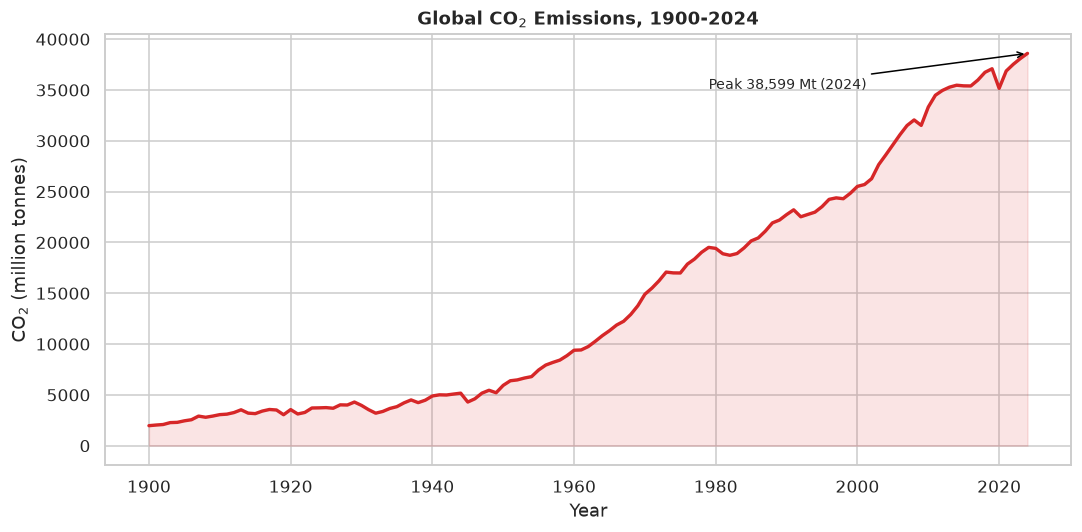

Global CO2  2024 = 38,599 Mt   |   1950 = 5,930 Mt   |   6.5x increase


In [5]:
w = world[world["year"] >= 1900].sort_values("year")
fig, ax = plt.subplots()
ax.plot(w["year"], w["co2"], color="#d62728", lw=2.2)
ax.fill_between(w["year"], 0, w["co2"], color="#d62728", alpha=0.12)
ax.set_title("Global CO$_2$ Emissions, 1900-2024")
ax.set_xlabel("Year"); ax.set_ylabel("CO$_2$ (million tonnes)")

peak_yr = int(w.loc[w["co2"].idxmax(), "year"]); peak_v = w["co2"].max()
ax.annotate(f"Peak {peak_v:,.0f} Mt ({peak_yr})",
            xy=(peak_yr, peak_v), xytext=(peak_yr - 45, peak_v - 3500),
            fontsize=9, arrowprops=dict(arrowstyle="->", color="black"))
plt.tight_layout(); plt.show()

v24 = float(w[w.year == 2024]["co2"].iloc[0])
v50 = float(w[w.year == 1950]["co2"].iloc[0])
print(f"Global CO2  2024 = {v24:,.0f} Mt   |   1950 = {v50:,.0f} Mt   |   {v24/v50:.1f}x increase")

#### 1b. Who emits the most — absolute vs. per-person (2023)

Absolute emissions expose the biggest national polluters; per-capita reveals the
most emission-intensive lifestyles. They tell very different stories.

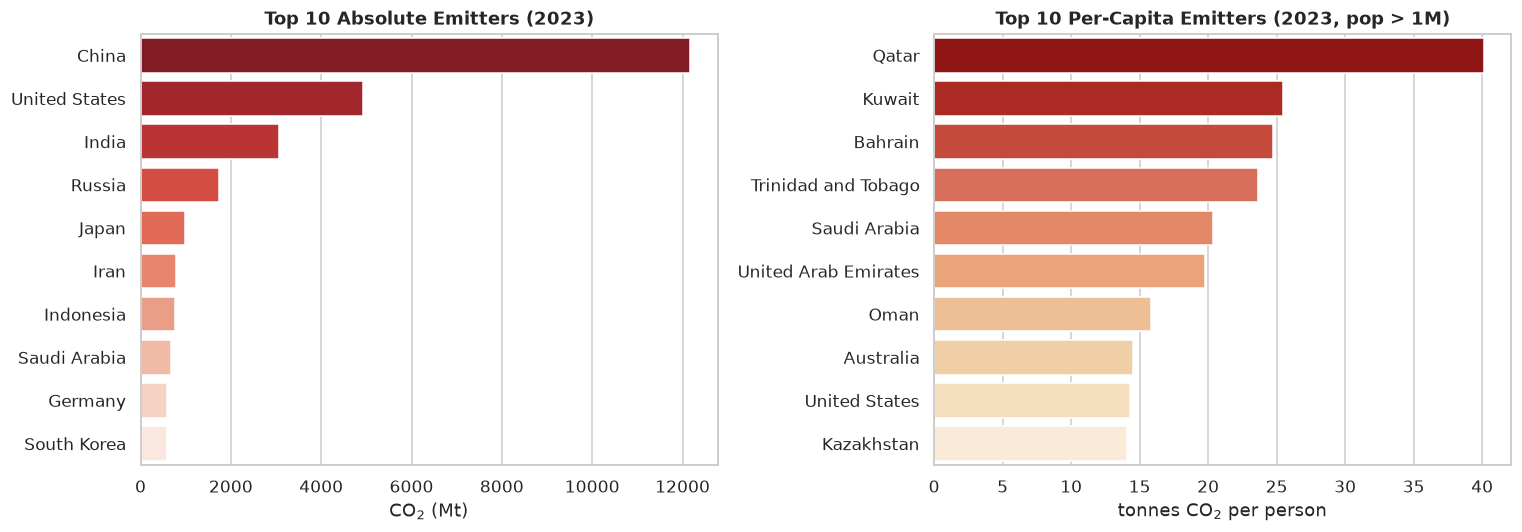

Absolute leaders : ['China', 'United States', 'India']
Per-capita leaders: ['Qatar', 'Kuwait', 'Bahrain']


In [6]:
latest = 2023  # last year with broad country-level coverage
top_em = countries[countries.year == latest].dropna(subset=["co2"]).nlargest(10, "co2")
top_pc = (countries[countries.year == latest]
          .dropna(subset=["co2_per_capita"]))
top_pc = top_pc[top_pc.population > 1e6].nlargest(10, "co2_per_capita")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=top_em, y="country", x="co2", ax=axes[0],
            hue="country", legend=False, palette="Reds_r")
axes[0].set_title(f"Top 10 Absolute Emitters ({latest})")
axes[0].set_xlabel("CO$_2$ (Mt)"); axes[0].set_ylabel("")

sns.barplot(data=top_pc, y="country", x="co2_per_capita", ax=axes[1],
            hue="country", legend=False, palette="OrRd_r")
axes[1].set_title(f"Top 10 Per-Capita Emitters ({latest}, pop > 1M)")
axes[1].set_xlabel("tonnes CO$_2$ per person"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

print("Absolute leaders :", list(top_em["country"][:3]))
print("Per-capita leaders:", list(top_pc["country"][:3]))

---
## 🟠 2. Diagnostic analysis — *Why did it happen?*

Now we ask *why* emissions are distributed this way. Two angles:

- **Driver check:** is economic output (GDP) the dominant correlate of emissions?
- **Composition check:** which fuels (coal / oil / gas / cement) make up the global total, and how is that mix shifting?

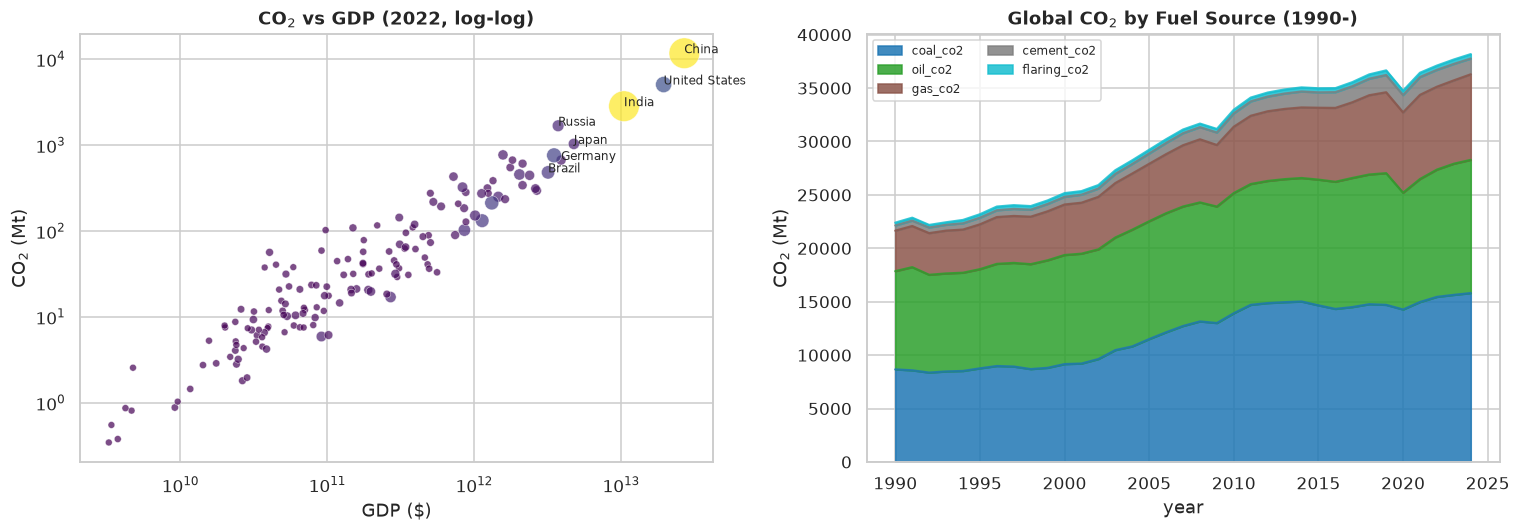

Countries analysed (2022): 153
log10 corr  GDP ~ CO2 : 0.948
log10 corr  POP ~ CO2 : 0.666
CO2-vs-GDP elasticity : 1.01  (≈ %101 CO2 per +1% GDP)


In [7]:
# Use 2022 - the latest year with broad GDP coverage (153 countries)
latest_g = 2022
rec = (countries[(countries.year == latest_g) & countries["gdp"].notna()
                 & countries["co2"].notna() & (countries.population > 1e6)].copy())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=rec, x="gdp", y="co2", size="population", hue="population",
                sizes=(20, 400), alpha=0.7, ax=axes[0], palette="viridis", legend=False)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title(f"CO$_2$ vs GDP ({latest_g}, log-log)")
axes[0].set_xlabel("GDP ($)"); axes[0].set_ylabel("CO$_2$ (Mt)")
for c in ["China", "United States", "India", "Russia", "Germany", "Japan", "Brazil"]:
    r = rec[rec.country == c]
    if len(r):
        axes[0].annotate(c, (r.gdp.iloc[0], r.co2.iloc[0]), fontsize=8)

wf = (world[world.year >= 1990]
      [["year", "coal_co2", "oil_co2", "gas_co2", "cement_co2", "flaring_co2"]]
      .set_index("year").sort_index())
wf.plot.area(ax=axes[1], cmap="tab10", alpha=0.85)
axes[1].set_title("Global CO$_2$ by Fuel Source (1990-)")
axes[1].set_ylabel("CO$_2$ (Mt)")
axes[1].legend(title="", ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

# Correlation & elasticity (slope in log-log ≈ %CO2 per %GDP)
r_g, r_c, r_p = np.log10(rec["gdp"]), np.log10(rec["co2"]), np.log10(rec["population"])
elasticity = np.polyfit(r_g, r_c, 1)[0]
print(f"Countries analysed ({latest_g}): {len(rec)}")
print(f"log10 corr  GDP ~ CO2 : {r_g.corr(r_c):.3f}")
print(f"log10 corr  POP ~ CO2 : {r_p.corr(r_c):.3f}")
print(f"CO2-vs-GDP elasticity : {elasticity:.2f}  (≈ %{elasticity*100:.0f} CO2 per +1% GDP)")

**What the diagnostics show:**
- GDP and CO₂ move almost in lockstep across countries (r ≈ 0.95) — economic scale is the
  dominant driver. The ~1.0 elasticity means a 1% larger economy maps to ~1% more CO₂.
- Population matters less than GDP (r ≈ 0.67): richer, not just bigger, countries emit more.
- On the composition side, **coal is still the single largest source** of global emissions,
  with gas and cement growing fastest since 1990.

#### 2b. Has anyone *decoupled* yet? — GDP up, CO₂ down

The GDP↔CO₂ correlation above looks inseparable, but it is a cross-sectional snapshot — it does
**not** prove growth *requires* emissions. The decisive test is *decoupling*: do any countries
grow their economy while *cutting* CO₂? Over **2010→2022, 37 of 97** sizeable economies did exactly
that, and global **carbon intensity fell ~32%** (CO₂ per dollar of GDP, 2000→2022). The transition
is already underway — including in the United States.

In [8]:
# Absolute decoupling: GDP rose while CO2 fell (2010 -> 2022, GDP > $50B)
d = (countries[countries.year.isin([2010, 2022])]
     .dropna(subset=["gdp", "co2"])
     .pivot(index="country", columns="year", values=["gdp", "co2"]))
d.columns = [f"{m}_{y}" for m, y in d.columns]
d = d[d["gdp_2010"] > 5e10].copy()
d["gdp_growth_%"]  = d.gdp_2022 / d.gdp_2010 - 1
d["co2_growth_%"]  = d.co2_2022 / d.co2_2010 - 1
decoupled = d[(d["gdp_growth_%"] > 0.05) & (d["co2_growth_%"] < 0)]\
            .sort_values("gdp_growth_%", ascending=False)

print(f"Tracked economies 2010-2022        : {len(d)}")
print(f"Absolute decouplers (GDP>5%, CO2<0): {len(decoupled)}")
print("\nTop decouplers (% change 2010-2022):")
print(decoupled[["gdp_growth_%", "co2_growth_%"]].head(12).mul(100).round(1)
      .to_string())

# Global carbon intensity: CO2 per $ of GDP (World), 2000 vs 2022
g0, c0 = float(world[world.year == 2000].gdp.iloc[0]), float(world[world.year == 2000].co2.iloc[0])
g1, c1 = float(world[world.year == 2022].gdp.iloc[0]), float(world[world.year == 2022].co2.iloc[0])
print(f"\nWorld carbon intensity: {c0/g0*1e9:.1f} -> {c1/g1*1e9:.1f} t CO2 per $1M GDP "
      f"({(c1/g1)/(c0/g0)-1:+.0%})")

Tracked economies 2010-2022        : 97
Absolute decouplers (GDP>5%, CO2<0): 37

Top decouplers (% change 2010-2022):
               gdp_growth_%  co2_growth_%
country                                  
Israel                 60.1          -8.8
Poland                 54.7          -5.7
Lithuania              51.3          -6.6
Romania                50.4         -13.4
New Zealand            43.8          -8.1
Hungary                42.3         -12.9
Ireland                39.0         -12.2
Australia              35.3          -5.2
Serbia                 32.7          -2.7
Slovenia               29.3         -22.7
United States          27.9         -10.8
Slovakia               27.1         -17.9

World carbon intensity: 0.4 -> 0.3 t CO2 per $1M GDP (-32%)


---
## 🟢 3. Predictive analysis — *What will happen?*

We fit a simple **linear regression** of global CO₂ against year using 2000–2024
(the era where absolute growth is near-linear) and project to 2035. The R² and a
±2σ band communicate how confident the projection is.

*(This is intentionally a transparent baseline; production climate forecasts use far
more sophisticated integrated-assessment models, but the workflow — fit, score,
project, quantify uncertainty — is identical.)*

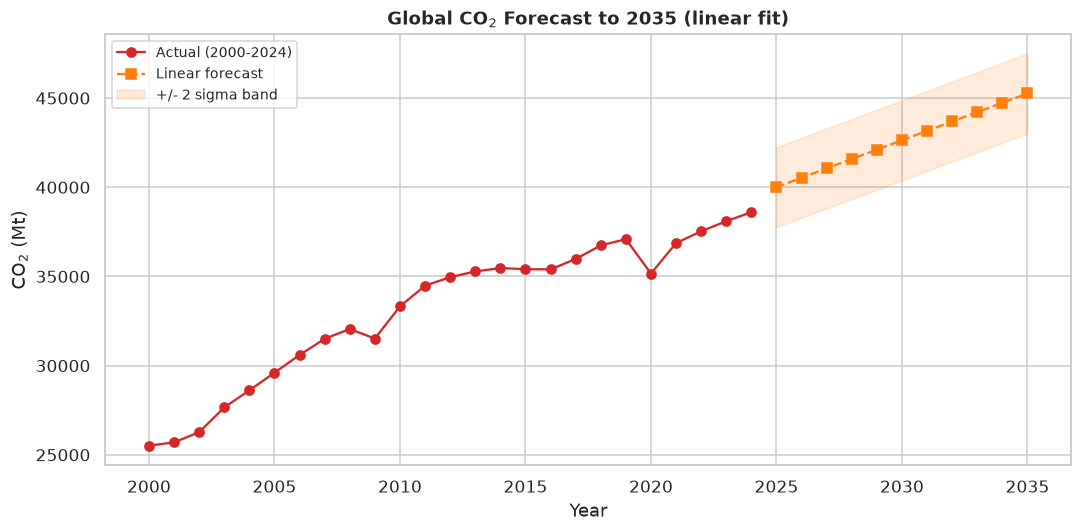

Model R^2      : 0.919
Learned slope  : 525.5 Mt per year
Projected 2030 : 42,632 Mt
Projected 2035 : 45,259 Mt  (+17% vs 2024)


In [9]:
hist = world[(world.year >= 2000) & (world.year <= 2024)].dropna(subset=["co2"]).sort_values("year")
X = hist[["year"]].values
y = hist["co2"].values
model = LinearRegression().fit(X, y)
pred_in = model.predict(X)
r2 = r2_score(y, pred_in)
sigma = np.std(y - pred_in)

future_yrs = np.arange(2025, 2036).reshape(-1, 1)
forecast = model.predict(future_yrs)

fig, ax = plt.subplots()
ax.plot(hist.year, y, "o-", color="#d62728", label="Actual (2000-2024)")
ax.plot(future_yrs.ravel(), forecast, "s--", color="#ff7f0e", label="Linear forecast")
ax.fill_between(future_yrs.ravel(), forecast - 2*sigma, forecast + 2*sigma,
                color="#ff7f0e", alpha=0.15, label="+/- 2 sigma band")
ax.set_title("Global CO$_2$ Forecast to 2035 (linear fit)")
ax.set_xlabel("Year"); ax.set_ylabel("CO$_2$ (Mt)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"Model R^2      : {r2:.3f}")
print(f"Learned slope  : {model.coef_[0]:,.1f} Mt per year")
print(f"Projected 2030 : {model.predict([[2030]])[0]:,.0f} Mt")
print(f"Projected 2035 : {forecast[-1]:,.0f} Mt  ({(forecast[-1]/y[-1]-1)*100:+.0f}% vs 2024)")

#### 3b. Is the straight line hiding a slowdown?

One line across 2000–2024 blends two different eras. Splitting the window shows growth has fallen
sharply — **+820 Mt/yr (2000–2012)** versus **+271 Mt/yr (2012–2024)**. The blended fit (+526 Mt/yr)
is dragged up by the fast 2000s and **over-projects 2035**. A recent-decade fit is the more
defensible baseline; its uncertainty band should also *widen* with horizon, unlike the flat ±2σ used
above.

In [10]:
# Growth has decelerated: compare slopes across windows
def slope(yr0, yr1):
    seg = world[(world.year >= yr0) & (world.year <= yr1)].dropna(subset=["co2"])
    m = LinearRegression().fit(seg[["year"]], seg["co2"])
    return m.coef_[0], len(seg)

print("Slope by window:")
for a, b in [(2000, 2012), (2012, 2024), (2000, 2024)]:
    s, n = slope(a, b)
    print(f"  {a}-{b} (n={n:>2}): +{s:,.0f} Mt/yr")

# Defensible projection from the recent decade only
seg = world[(world.year >= 2012) & (world.year <= 2024)].dropna(subset=["co2"])
m_recent = LinearRegression().fit(seg[["year"]], seg["co2"])
print(f"\n2035 projection  | recent-decade fit: {m_recent.predict([[2035]])[0]:,.0f} Mt")
print(f"                 | blended 2000-2024 : {model.predict([[2035]])[0]:,.0f} Mt"
      f"  (over-projects by ~{(model.predict([[2035]])[0]/m_recent.predict([[2035]])[0]-1)*100:.0f}%)")

Slope by window:
  2000-2012 (n=13): +820 Mt/yr
  2012-2024 (n=13): +271 Mt/yr
  2000-2024 (n=25): +526 Mt/yr

2035 projection  | recent-decade fit: 40,948 Mt
                 | blended 2000-2024 : 45,259 Mt  (over-projects by ~11%)


---
## 🟣 4. Prescriptive analysis — *What should we do?*

Forecasting tells us where we are *headed*; prescription asks what action would move us
onto a different path. Here we turn the model into a **decision lever**: given a target
for 2035, what constant annual reduction rate is required to reach it?

Three scenarios:
1. **Business-as-usual** — linear growth continues.
2. **Flat** — hold emissions at the 2024 level through 2035.
3. **Halve by 2035** — a Paris-style deep-cut ambition.

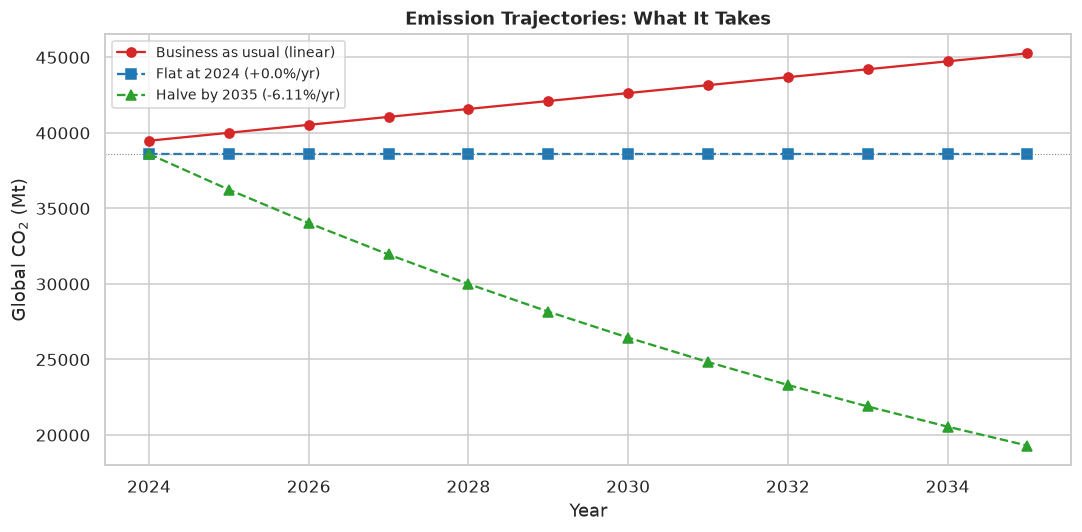

2024 baseline                      : 38,599 Mt
Business-as-usual 2035             : 45,259 Mt  (+17% vs 2024)
Halve by 2035 requires             : -6.11%/yr every year to 2035


In [11]:
base_2024 = float(world[world.year == 2024]["co2"].iloc[0])
n_years = 2035 - 2024
bau_2035 = float(model.predict([[2035]])[0])

def annual_rate(start, target, n):
    return 100 * ((target / start) ** (1 / n) - 1)

flat_rate = annual_rate(base_2024, base_2024, n_years)          # 0 by construction
halve_rate = annual_rate(base_2024, base_2024 / 2, n_years)

yrs = np.arange(2024, 2036)
bau_path = model.predict(yrs.reshape(-1, 1))
flat_path = base_2024 * np.ones_like(yrs, dtype=float)
half_path = base_2024 * (0.5) ** ((yrs - 2024) / n_years)

fig, ax = plt.subplots()
ax.plot(yrs, bau_path, "o-", label="Business as usual (linear)", color="#d62728")
ax.plot(yrs, flat_path, "s--", label=f"Flat at 2024 ({flat_rate:+.1f}%/yr)", color="#1f77b4")
ax.plot(yrs, half_path, "^--", label=f"Halve by 2035 ({halve_rate:+.2f}%/yr)", color="#2ca02c")
ax.axhline(base_2024, color="grey", lw=0.7, ls=":")
ax.set_title("Emission Trajectories: What It Takes")
ax.set_xlabel("Year"); ax.set_ylabel("Global CO$_2$ (Mt)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"2024 baseline                      : {base_2024:,.0f} Mt")
print(f"Business-as-usual 2035             : {bau_2035:,.0f} Mt  ({(bau_2035/base_2024-1)*100:+.0f}% vs 2024)")
print(f"Halve by 2035 requires             : {halve_rate:+.2f}%/yr every year to 2035")

#### 4b. Whose cut is it anyway? — current vs. historical responsibility

A flat global reduction rate is politically inert. Responsibility looks very different on a
*cumulative* (historical) basis: the **United States leads with ~24%** of all-time emissions, ahead
of China (~16%) — the **opposite** of the current annual ranking (China first). The top 10 account
for ~70% of cumulative CO₂. A fair-share path would weight each country's obligation against *both*
its current and its historical share.

In [12]:
# Cumulative (historical) responsibility vs the current annual ranking
latest_cum = (countries.sort_values("year", ascending=False)
              .drop_duplicates("country", keep="first")
              .dropna(subset=["cumulative_co2"]))
total = latest_cum["cumulative_co2"].sum()
top10 = latest_cum.nlargest(10, "cumulative_co2")[["country", "cumulative_co2"]]
out = top10.assign(share_pct=top10.cumulative_co2 / total * 100)
print(f"World cumulative CO2 (sum of countries): {total:,.0f} Mt  (~{total/1000:,.0f} Gt)")
print("\nTop 10 cumulative emitters (historical responsibility):")
print(out.round({"cumulative_co2": 0, "share_pct": 1}).to_string(index=False))
print(f"\nTop-10 combined share: {top10['cumulative_co2'].sum()/total*100:.1f}%")
print("(Rank flips vs annual: US > China historically, China > US today.)")

World cumulative CO2 (sum of countries): 1,803,057 Mt  (~1,803 Gt)

Top 10 cumulative emitters (historical responsibility):
       country  cumulative_co2  share_pct
 United States        434867.0       24.1
         China        285087.0       15.8
        Russia        122808.0        6.8
       Germany         95136.0        5.3
United Kingdom         80079.0        4.4
         Japan         69612.0        3.9
         India         66073.0        3.7
        France         40048.0        2.2
        Canada         35644.0        2.0
       Ukraine         31236.0        1.7

Top-10 combined share: 69.9%
(Rank flips vs annual: US > China historically, China > US today.)


---
## Key findings & recap

**On the data:**
- Global CO₂ rose from ~5,930 Mt (1950) to **~38,600 Mt (2024)** — a **6.5× increase**.
- **China, the United States, India** lead on absolute emissions; **Qatar, Kuwait, Bahrain**
  lead per capita — the two rankings barely overlap.
- **GDP is the dominant driver** (log-log r ≈ 0.95, elasticity ≈ 1.0); population is weaker (r ≈ 0.67).
- **Coal remains the #1 fuel source**, though gas and cement have grown fastest since 1990.

**On the analysis types — how each contributed here:**

| Type | What it produced | Tools used |
|------|------------------|------------|
| **Descriptive** | The 6.5× growth curve, top-emitter rankings | `pandas` summaries, line/bar plots |
| **Diagnostic** | GDP↔CO₂ correlation, fuel-source decomposition | scatter/log-log, correlation, stacked area |
| **Predictive** | A linear model (R² ≈ 0.92) projecting ~45 Gt by 2035 | `scikit-learn` `LinearRegression` |
| **Prescriptive** | A decision lever: ~**-6.1 %/yr** cuts needed to halve by 2035 | scenario / what-if modelling |

**Bottom line:** the four analytics types form a ladder — *describe → explain → forecast →
act*. Each rung builds on the previous one's evidence, turning raw history into an
actionable recommendation.
---

## 🔎 Deeper findings (added analysis)

Three results strengthen the four-type walkthrough above — each was computed from this same dataset:

- **Decoupling is real and already happening.** 37 of 97 economies grew GDP >5% while *cutting* CO₂
  (2010–2022) — including the **United States** (+28% GDP, −11% CO₂). Global carbon intensity fell
  ~32% (CO₂ per $ of GDP, 2000→2022). Growth and emissions are *not* inseparable; the prescriptive
  target is demonstrably achievable.
- **The naive linear forecast over-projects.** Growth slowed from +820 Mt/yr (2000–2012) to
  +271 Mt/yr (2012–2024); the blended 2000–2024 fit (+526 Mt/yr) inherits the fast 2000s and lands
  ~45.3 Gt by 2035, above what a recent-decade fit would suggest. Report regime-aware slopes.
- **Responsibility is not symmetric.** Cumulative (historical) CO₂ puts the **US first (~24%)**,
  ahead of China (~16%) — the reverse of today's annual ranking. Top-10 nations = ~70% of all-time
  emissions, so a flat global "−6%/yr" should be replaced with differentiated, fair-share cuts.


---
## 🎯 How to reduce / fix this — data-backed recommendations

The four analyses above don't just describe the problem — they point at levers. Every recommendation
below is tied to a number this notebook computed from `owid-co2-data.csv`.

| Priority | Do this | Why — evidence from the data |
|:---:|---|---|
| **1** | **Phase out coal first** — retire/abate coal-fired power as the top climate lever | Coal is **40.9%** of 2024 emissions, the single largest source. Removing 1 Gt of coal CO₂ cuts ~2.6% off the global total — the biggest bang per unit of effort. |
| **2** | **Target the *rising* sources** — industrial policy for cement & gas (CCS, green cement, electrify heat) | Cement **+199%** and gas **+111%** since 1990 are the *growing* slices; cutting them stops the leak, not just the biggest pool. |
| **3** | **Replicate the decouplers** — scale the policies that let 37 countries grow GDP while cutting CO₂ | The US grew GDP **+28%** while CO₂ fell **−11%**; Czechia **−19%**, Romania **−13%**. Decoupling is proven, not theoretical — global carbon intensity already dropped **−32%**. |
| **4** | **Differentiate responsibility** — weight cuts by current *and* historical emissions, not a flat global rate | Top-10 nations hold **~70%** of all-time CO₂ (US 24%, China 16% vs their flipped annual ranks). The heaviest lift belongs to the biggest cumulative emitters. |
| **5** | **Accelerate the bend** — turn the recent deceleration into net annual cuts | Growth already slowed **+820 → +271 Mt/yr** (2000–12 → 2012–24); the curve is bending. The goal — halving by 2035 — needs **−6.1%/yr every single year**. |

**Bottom line:** the data says the transition is both possible *and already underway*. The fix is not
mystery technology — it is **coal first, then the fast-rising industrial sources, copying the playbook
of the 37 countries that already decoupled, with the largest historical emitters carrying the largest
share, accelerated fast enough to hold ~−6%/yr.** The forecast told us where we are headed; the table
above is how to change course.